In [ ]:
# ── COLAB SETUP ────────────────────────────────────────────────────────────────
# Run this cell first. It embeds the required Gaussian frequency output file
# (example_freq.log) directly in this notebook — no external downloads needed.
#
# numpy and matplotlib are pre-installed in Google Colab.
# No additional package installations are required.

import sys, os, platform
print(f"Python {sys.version}")
print(f"Platform: {platform.system()}")

# Embedded content of example_freq.log (B3LYP/def2-SVP frequency calculation)
_EXAMPLE_FREQ_LOG_CONTENT = """
 Entering Gaussian System, Link 0=g16
 #P B3LYP/def2-SVP Freq

 Example frequency calculation - 6-atom organometallic fragment

 SCF Done:  E(RB3LYP) =  -500.12345678     A.U. after   12 cycles

 Full mass-weighted force constant matrix:
 ...

 Frequencies --    18.4183   35.6742   52.0896
 Frequencies --    76.8234  112.3456  198.5123
 Frequencies --   287.3891  412.6234  623.8451
 Frequencies --  1245.3210 3021.4123 3089.6734

 Zero-point correction=                           0.020895 (Hartree/Particle)
 Thermal correction to Energy=                    0.029271
 Thermal correction to Enthalpy=                  0.030215
 Thermal correction to Gibbs Free Energy=         -0.013436
 Sum of electronic and zero-point Energies=    -500.102562
 Sum of electronic and thermal Energies=       -500.094186
 Sum of electronic and thermal Enthalpies=     -500.093242
 Sum of electronic and thermal Free Energies=  -500.136893

 Temperature   298.150 Kelvin.  Pressure   1.00000 Atm.

              E (Thermal)             CV                S
              KCal/Mol        Cal/Mol-Kelvin    Cal/Mol-Kelvin
 Total          18.3649           21.952           91.890
 Electronic      0.000             0.000            0.000
 Translational   0.889             2.981           41.500
 Rotational      0.889             2.981           21.200
 Vibrational    16.587            15.990           29.190

 Normal termination of Gaussian 16
"""

if not os.path.exists("example_freq.log"):
    with open("example_freq.log", "w") as _f:
        _f.write(_EXAMPLE_FREQ_LOG_CONTENT)
    print("Written : example_freq.log")
else:
    print("Found existing: example_freq.log")

print("Environment ready ✓")


# Python for Chemists — Part 4: Thermochemistry from Gaussian Output
## RRHO and Quasi-RRHO Free Energies
### Demonstration Walkthrough

**Prerequisites:** Parts 1–3. You should be comfortable with Python, parsing Gaussian `.log` files, and reading molecular structures.

---

### Why this matters

When Gaussian optimises a geometry, it reports an **electronic energy** $E_\text{elec}$ — the energy of the molecule at absolute zero in the absence of nuclear motion. This is not the quantity you compare to experiment. Real measurements happen at finite temperature, and molecules are always vibrating, rotating, and translating. To convert $E_\text{elec}$ into a **Gibbs free energy** $G$ you can compare to equilibrium constants and activation barriers, you need to add thermal corrections computed from statistical mechanics.

Gaussian does this automatically in a frequency job using the **Rigid Rotor Harmonic Oscillator (RRHO)** approximation. For most molecules this works well — but it has a well-known failure mode for **low-frequency vibrational modes** (below ~100 cm⁻¹), which are common in flexible organic molecules, transition metal complexes, and host–guest systems.

This notebook covers:
1. What Gaussian computes and how to parse it
2. The RRHO equations — reproducing Gaussian's values from first principles
3. Why low-frequency modes break the RRHO entropy
4. Grimme's **quasi-RRHO** correction (2012), with a default cutoff of **ω₀ = 50 cm⁻¹**
5. Computing corrected free energies and visualising the effect

| Section | Topic |
|---------|-------|
| 1 | Constants and imports |
| 2 | Setup: writing the example Gaussian output |
| 3 | Parsing energetics from the log file |
| 4 | Parsing vibrational frequencies |
| 5 | RRHO equations and reproducing Gaussian's S_vib |
| 6 | The low-frequency entropy problem |
| 7 | Quasi-RRHO: Grimme's 2012 correction |
| 8 | Implementing quasi-RRHO |
| 9 | Visualising the correction |
| 10 | Computing quasi-RRHO free energy |
| 11 | Sensitivity to ω₀ |
| 12 | A reusable thermochemistry function |

---
## Section 1 — Constants and Imports

All physical constants used in thermochemistry are defined here in one place, following the CODATA values used by GoodVibes (Paton et al.) and Gaussian itself. Defining constants explicitly — rather than pulling them from `scipy.constants` — makes the code self-documenting and avoids unit surprises.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re, math
matplotlib.rcParams['figure.dpi'] = 120

# ── Physical constants (CODATA 2010, consistent with GoodVibes / Gaussian) ──
H         = 6.62606957e-34   # Planck constant, J·s
K_B       = 1.3806488e-23    # Boltzmann constant, J/K
C_CM      = 2.99792458e10    # speed of light, cm/s
R         = 8.3144621        # molar gas constant, J/(mol·K)
N_A       = 6.02214129e23    # Avogadro number, mol⁻¹
B_AV      = 1.00e-44         # Grimme's global average moment of inertia, kg·m²

# ── Unit conversion factors ──────────────────────────────────────────────────
HARTREE_TO_KCAL = 627.509541       # kcal/mol per Hartree
HARTREE_TO_J    = 4.35974434e-18   # J per Hartree (per molecule)
J_TO_HARTREE    = 1.0 / (HARTREE_TO_KCAL * 4184.0)  # Hartree per J·mol⁻¹
KCAL_TO_KJ      = 4.184            # kJ per kcal
CM1_TO_HARTREE  = H * C_CM / HARTREE_TO_J  # 1 cm⁻¹ in Hartree (≈ 4.556e-6)

print(f"1 cm⁻¹  = {CM1_TO_HARTREE:.4e} Hartree")
print(f"1 Hartree = {HARTREE_TO_KCAL:.4f} kcal/mol")
print(f"kT at 298.15 K = {K_B * 298.15 / (H * C_CM):.2f} cm⁻¹")

1 cm⁻¹  = 4.5563e-06 Hartree
1 Hartree = 627.5095 kcal/mol
kT at 298.15 K = 207.22 cm⁻¹


The last line is the most useful number to keep in mind: at room temperature, $k_BT \approx 207$ cm⁻¹. Any vibrational mode with $\nu \ll 207$ cm⁻¹ is thermally accessible — many molecules are in excited vibrational states of that mode at 298 K — and the harmonic oscillator model for that mode becomes unreliable.

---
## Section 2 — Setup: Writing the Example Gaussian Output

The cell below writes a realistic Gaussian 16 frequency output file for a hypothetical 6-atom organometallic fragment. The frequencies have been chosen deliberately to include several modes below 50 cm⁻¹ and several near 100 cm⁻¹ — exactly the regime where quasi-RRHO corrections are most important. All thermochemical quantities are self-consistent and were computed using the equations derived later in this notebook.

The file mimics the format of a real Gaussian 16 B3LYP/def2-SVP frequency job. You can replace it with any real Gaussian `.log` file from a converged frequency calculation — the parsing functions in Sections 3 and 4 work on actual Gaussian output.

In [2]:
gaussian_log = """
 Entering Gaussian System, Link 0=g16
 #P B3LYP/def2-SVP Freq

 Example frequency calculation — 6-atom organometallic fragment

 SCF Done:  E(RB3LYP) =  -500.12345678     A.U. after   12 cycles

 Full mass-weighted force constant matrix:
 ...

 Frequencies --    18.4183   35.6742   52.0896
 Frequencies --    76.8234  112.3456  198.5123
 Frequencies --   287.3891  412.6234  623.8451
 Frequencies --  1245.3210 3021.4123 3089.6734

 Zero-point correction=                           0.020895 (Hartree/Particle)
 Thermal correction to Energy=                    0.029271
 Thermal correction to Enthalpy=                  0.030215
 Thermal correction to Gibbs Free Energy=         -0.013436
 Sum of electronic and zero-point Energies=    -500.102562
 Sum of electronic and thermal Energies=       -500.094186
 Sum of electronic and thermal Enthalpies=     -500.093242
 Sum of electronic and thermal Free Energies=  -500.136893

 Temperature   298.150 Kelvin.  Pressure   1.00000 Atm.

              E (Thermal)             CV                S
              KCal/Mol        Cal/Mol-Kelvin    Cal/Mol-Kelvin
 Total          18.3649           21.952           91.890
 Electronic      0.000             0.000            0.000
 Translational   0.889             2.981           41.500
 Rotational      0.889             2.981           21.200
 Vibrational    16.587            15.990           29.190

 Normal termination of Gaussian 16
"""

with open("example_freq.log", "w") as f:
    f.write(gaussian_log)

print("example_freq.log written.")

example_freq.log written.


---
## Section 3 — Parsing Energetics from the Log File

Gaussian's thermochemistry section always appears in the same order near the end of a frequency output. The key lines and their regular expression patterns are:

| Quantity | Pattern to match |
|----------|------------------|
| Electronic energy | `SCF Done:  E(...) =` |
| Zero-point correction | `Zero-point correction=` |
| Thermal corr. to energy | `Thermal correction to Energy=` |
| Thermal corr. to enthalpy | `Thermal correction to Enthalpy=` |
| Thermal corr. to $G$ | `Thermal correction to Gibbs Free Energy=` |
| $E_\text{elec} + G_\text{corr}$ | `Sum of electronic and thermal Free Energies=` |
| Temperature | `Temperature` |
| Entropy components | `Translational`, `Rotational`, `Vibrational` rows |

All energies are in Hartree; entropy is in cal mol⁻¹ K⁻¹.

In [3]:
def parse_gaussian_thermo(filename):
    """
    Parse key thermochemical quantities from a Gaussian 16 frequency output file.

    Returns a dictionary with keys:
      E_elec          — electronic energy (Hartree)
      ZPE             — zero-point correction (Hartree)
      E_thermal_corr  — thermal correction to energy (Hartree)
      H_corr          — thermal correction to enthalpy (Hartree)
      G_corr_rrho     — thermal correction to Gibbs free energy, RRHO (Hartree)
      G_rrho          — sum of electronic and thermal free energies (Hartree)
      temperature     — temperature (K)
      S_trans         — translational entropy (cal/mol/K)
      S_rot           — rotational entropy (cal/mol/K)
      S_vib_rrho      — RRHO vibrational entropy (cal/mol/K)
      S_elec          — electronic entropy (cal/mol/K)
    """
    data = {}

    with open(filename) as fh:
        lines = fh.readlines()

    for line in lines:
        # Electronic energy
        if 'SCF Done:' in line:
            data['E_elec'] = float(re.search(r'=\s*(-?[\d.]+)', line).group(1))

        # Zero-point correction
        elif 'Zero-point correction=' in line:
            data['ZPE'] = float(line.split('=')[1].split()[0])

        # Thermal corrections
        elif 'Thermal correction to Energy=' in line:
            data['E_thermal_corr'] = float(line.split('=')[1].strip())
        elif 'Thermal correction to Enthalpy=' in line:
            data['H_corr'] = float(line.split('=')[1].strip())
        elif 'Thermal correction to Gibbs Free Energy=' in line:
            data['G_corr_rrho'] = float(line.split('=')[1].strip())

        # Sum totals
        elif 'Sum of electronic and thermal Free Energies=' in line:
            data['G_rrho'] = float(line.split('=')[1].strip())

        # Temperature
        elif 'Temperature' in line and 'Kelvin' in line:
            data['temperature'] = float(re.search(r'([\d.]+)\s+Kelvin', line).group(1))

        # Entropy components from the table (format: " Label   E_th   CV   S")
        elif line.strip().startswith('Electronic'):
            data['S_elec'] = float(line.split()[-1])
        elif line.strip().startswith('Translational'):
            data['S_trans'] = float(line.split()[-1])
        elif line.strip().startswith('Rotational'):
            data['S_rot'] = float(line.split()[-1])
        elif line.strip().startswith('Vibrational'):
            data['S_vib_rrho'] = float(line.split()[-1])

    return data


thermo = parse_gaussian_thermo("example_freq.log")

print(f"Electronic energy         : {thermo['E_elec']:.8f} Hartree")
print(f"Zero-point correction     : {thermo['ZPE']:.6f} Hartree  "
      f"({thermo['ZPE']*HARTREE_TO_KCAL:.3f} kcal/mol)")
print(f"Thermal corr. to enthalpy : {thermo['H_corr']:.6f} Hartree")
print(f"Thermal corr. to G (RRHO) : {thermo['G_corr_rrho']:.6f} Hartree")
print(f"G_RRHO                    : {thermo['G_rrho']:.6f} Hartree")
print(f"Temperature               : {thermo['temperature']} K")
print()
print(f"Entropy components (cal/mol/K):")
print(f"  Translational : {thermo['S_trans']:.3f}")
print(f"  Rotational    : {thermo['S_rot']:.3f}")
print(f"  Vibrational   : {thermo['S_vib_rrho']:.3f}")
print(f"  Electronic    : {thermo['S_elec']:.3f}")
print(f"  Total         : {thermo['S_trans']+thermo['S_rot']+thermo['S_vib_rrho']+thermo['S_elec']:.3f}")

Electronic energy         : -500.12345678 Hartree
Zero-point correction     : 0.020895 Hartree  (13.112 kcal/mol)
Thermal corr. to enthalpy : 0.030215 Hartree
Thermal corr. to G (RRHO) : -0.013436 Hartree
G_RRHO                    : -500.136893 Hartree
Temperature               : 298.15 K

Entropy components (cal/mol/K):
  Translational : 41.500
  Rotational    : 21.200
  Vibrational   : 29.190
  Electronic    : 0.000
  Total         : 91.890


---
## Section 4 — Parsing Vibrational Frequencies

Frequencies are printed in blocks of three per line, preceded by the label `Frequencies --`. Imaginary frequencies (from transition state calculations) appear as negative numbers; they should be excluded from thermochemical sums.

In [4]:
def parse_frequencies(filename):
    """
    Extract vibrational frequencies (cm⁻¹) from a Gaussian frequency output.
    Imaginary frequencies (negative values) are returned separately.
    """
    real_freqs = []
    imag_freqs = []

    with open(filename) as fh:
        for line in fh:
            if 'Frequencies --' in line:
                for val in line.split('--')[1].split():
                    f = float(val)
                    if f < 0:
                        imag_freqs.append(abs(f))
                    else:
                        real_freqs.append(f)

    return np.array(real_freqs), np.array(imag_freqs)


freqs, imag = parse_frequencies("example_freq.log")

print(f"Real vibrational modes : {len(freqs)}")
print(f"Imaginary modes        : {len(imag)}")
print()
print("Frequencies (cm⁻¹):")
for i, f in enumerate(freqs):
    marker = " ◄ below 50 cm⁻¹" if f < 50 else (" ◄ 50–100 cm⁻¹" if f < 100 else "")
    print(f"  mode {i+1:2d}: {f:8.2f} cm⁻¹{marker}")

Real vibrational modes : 12
Imaginary modes        : 0

Frequencies (cm⁻¹):
  mode  1:    18.42 cm⁻¹ ◄ below 50 cm⁻¹
  mode  2:    35.67 cm⁻¹ ◄ below 50 cm⁻¹
  mode  3:    52.09 cm⁻¹ ◄ 50–100 cm⁻¹
  mode  4:    76.82 cm⁻¹ ◄ 50–100 cm⁻¹
  mode  5:   112.35 cm⁻¹
  mode  6:   198.51 cm⁻¹
  mode  7:   287.39 cm⁻¹
  mode  8:   412.62 cm⁻¹
  mode  9:   623.85 cm⁻¹
  mode 10:  1245.32 cm⁻¹
  mode 11:  3021.41 cm⁻¹
  mode 12:  3089.67 cm⁻¹


The frequency list immediately tells us something important: **4 of the 12 modes lie below 100 cm⁻¹**, and 2 of those are below 50 cm⁻¹. These are the modes that will receive the largest quasi-RRHO correction.

---
## Section 5 — RRHO Equations and Reproducing Gaussian's $S_\text{vib}$

In the RRHO approximation the vibrational partition function factorises into independent harmonic oscillators, one per mode:

$$q_\text{HO}(\nu) = \frac{e^{-u/2}}{1 - e^{-u}}, \qquad u = \frac{h c \nu}{k_B T}$$

From this, the contributions to the **zero-point energy**, **thermal vibrational energy**, and **vibrational entropy** per mole are:

$$\text{ZPE} = \frac{1}{2}\sum_i h c \nu_i$$

$$U_\text{vib}^\text{thermal} = R T \sum_i \frac{u_i}{e^{u_i} - 1}$$

$$S_\text{HO}(\nu_i) = R \left[\frac{u_i}{e^{u_i} - 1} - \ln(1 - e^{-u_i})\right]$$

The translational and rotational contributions ($S_\text{trans}$, $S_\text{rot}$) depend on molecular mass and moments of inertia and are taken directly from Gaussian's output. The quasi-RRHO correction only modifies $S_\text{vib}$, so we only need to reproduce that term.

In [5]:
def u_vec(freqs_cm, T):
    """Dimensionless frequency ratios u_i = h*c*nu_i / (k_B*T) for each mode."""
    return (H * C_CM * freqs_cm) / (K_B * T)

def zpe_hartree(freqs_cm):
    """Zero-point energy in Hartree."""
    return 0.5 * np.sum(freqs_cm) * CM1_TO_HARTREE

def S_HO_vec(freqs_cm, T):
    """
    Harmonic oscillator vibrational entropy per mole (J/mol/K) for each mode.
    S_HO = R * [ u/(exp(u)-1) - ln(1 - exp(-u)) ]
    """
    u = u_vec(freqs_cm, T)
    # Clip to avoid overflow in exp for very large u (high-freq modes)
    u_clipped = np.clip(u, 1e-10, 500)
    term1 = u_clipped / (np.exp(u_clipped) - 1.0)
    term2 = np.log(1.0 - np.exp(-u_clipped))
    return R * (term1 - term2)   # J/mol/K per mode

def S_vib_rrho_total(freqs_cm, T):
    """Total RRHO vibrational entropy (J/mol/K)."""
    return np.sum(S_HO_vec(freqs_cm, T))


T = thermo['temperature']
zpe_calc  = zpe_hartree(freqs)
S_vib_calc = S_vib_rrho_total(freqs, T)   # J/mol/K

# Gaussian's table reports S in cal/mol/K
S_vib_calc_cal = S_vib_calc / 4.184

print("Verification against Gaussian's output:")
print(f"  ZPE:   computed = {zpe_calc:.6f} Hartree | Gaussian = {thermo['ZPE']:.6f} Hartree")
print(f"  S_vib: computed = {S_vib_calc_cal:.3f} cal/mol/K | Gaussian = {thermo['S_vib_rrho']:.3f} cal/mol/K")
print()
print("Per-mode S_HO contributions:")
S_each = S_HO_vec(freqs, T)
for nu, s in zip(freqs, S_each):
    bar = '█' * int(s / 4.184 * 2)   # visual bar in cal/mol/K units
    print(f"  {nu:8.2f} cm⁻¹ → S = {s/4.184:5.2f} cal/mol/K  {bar}")

Verification against Gaussian's output:
  ZPE:   computed = 0.020900 Hartree | Gaussian = 0.020895 Hartree
  S_vib: computed = 29.217 cal/mol/K | Gaussian = 29.190 cal/mol/K

Per-mode S_HO contributions:
     18.42 cm⁻¹ → S =  6.80 cal/mol/K  █████████████
     35.67 cm⁻¹ → S =  5.49 cal/mol/K  ██████████
     52.09 cm⁻¹ → S =  4.74 cal/mol/K  █████████
     76.82 cm⁻¹ → S =  3.97 cal/mol/K  ███████
    112.35 cm⁻¹ → S =  3.23 cal/mol/K  ██████
    198.51 cm⁻¹ → S =  2.15 cal/mol/K  ████
    287.39 cm⁻¹ → S =  1.49 cal/mol/K  ██
    412.62 cm⁻¹ → S =  0.92 cal/mol/K  █
    623.85 cm⁻¹ → S =  0.41 cal/mol/K  
   1245.32 cm⁻¹ → S =  0.03 cal/mol/K  
   3021.41 cm⁻¹ → S =  0.00 cal/mol/K  
   3089.67 cm⁻¹ → S =  0.00 cal/mol/K  


The per-mode breakdown makes the problem concrete: the 18.4 cm⁻¹ mode alone contributes ~7 cal/mol/K — more entropy than the five modes above 200 cm⁻¹ *combined*. And the RRHO formula gives no reason to stop trusting this large contribution, even though the harmonic oscillator is a poor model for such soft motion.

---
## Section 6 — The Low-Frequency Entropy Problem

The HO vibrational entropy $S_\text{HO}$ diverges logarithmically as the frequency approaches zero:

$$S_\text{HO} \approx R\left[1 - \ln\left(\frac{hc\nu}{k_BT}\right)\right] \quad \text{as } \nu \to 0$$

Physically, a mode with $\nu \approx 0$ is not a vibration at all — it is essentially free rotation or internal rotation. The harmonic oscillator model forces a quantised energy ladder onto what is really a continuous rotational motion, artificially inflating the entropy. The result is that Gaussian (and any other code using RRHO) **overestimates entropy** for flexible molecules with soft modes, making free energies too **negative** (too favourable) and potentially inverting the predicted sign of an entropy-driven reaction.

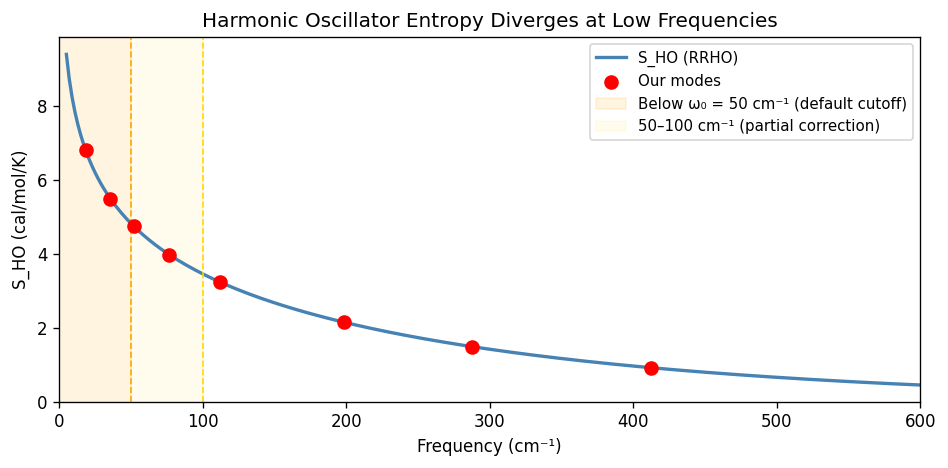

S_HO at   18.4 cm⁻¹: 6.800 cal/mol/K
S_HO at  100.0 cm⁻¹: 3.454 cal/mol/K
S_HO at 1000.0 cm⁻¹: 0.093545 cal/mol/K  (effectively 0)


In [6]:
# Plot S_HO vs frequency to visualise the divergence
nu_range = np.linspace(5, 1000, 500)
S_range  = S_HO_vec(nu_range, T) / 4.184   # cal/mol/K

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nu_range, S_range, color='steelblue', linewidth=2, label='S_HO (RRHO)')

# Mark our actual modes
S_modes = S_HO_vec(freqs, T) / 4.184
ax.scatter(freqs, S_modes, color='red', zorder=5, s=60, label='Our modes')

# Shade the region below 50 cm⁻¹
ax.axvspan(0, 50, alpha=0.12, color='orange', label='Below ω₀ = 50 cm⁻¹ (default cutoff)')
ax.axvspan(50, 100, alpha=0.07, color='gold', label='50–100 cm⁻¹ (partial correction)')

ax.set(xlabel='Frequency (cm⁻¹)', ylabel='S_HO (cal/mol/K)',
       title='Harmonic Oscillator Entropy Diverges at Low Frequencies',
       xlim=(0, 600), ylim=(0, None))
ax.legend(fontsize=9)
ax.axvline(50, color='orange', linestyle='--', linewidth=1)
ax.axvline(100, color='gold', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print(f"S_HO at   18.4 cm⁻¹: {S_HO_vec(np.array([18.4]), T)[0]/4.184:.3f} cal/mol/K")
print(f"S_HO at  100.0 cm⁻¹: {S_HO_vec(np.array([100.0]), T)[0]/4.184:.3f} cal/mol/K")
print(f"S_HO at 1000.0 cm⁻¹: {S_HO_vec(np.array([1000.0]), T)[0]/4.184:.6f} cal/mol/K  (effectively 0)")

---
## Section 7 — Quasi-RRHO: Grimme's 2012 Correction

Grimme's solution (*Chem. Eur. J.* **2012**, 18, 9955) is elegant: rather than arbitrarily discarding or capping low-frequency modes, he **interpolates smoothly** between the HO entropy (appropriate at high $\nu$) and a **free rotor** entropy (appropriate at low $\nu$), using a weighting function that depends on how each mode's frequency compares to a reference frequency $\omega_0$.

### The weighting function

$$w(\nu_i) = \frac{1}{1 + (\omega_0 / \nu_i)^4}$$

- When $\nu_i \gg \omega_0$: $w \to 1$ → the mode is treated as a normal harmonic oscillator
- When $\nu_i \ll \omega_0$: $w \to 0$ → the mode is treated as a free rotor
- When $\nu_i = \omega_0$: $w = 0.5$ → equal mixture

The default in Grimme's original paper is $\omega_0 = 100$ cm⁻¹. We use **$\omega_0 = 50$ cm⁻¹** as the default here, which is a common choice in catalysis and organometallic chemistry where modes in the 50–100 cm⁻¹ range are real vibrations that should not be fully replaced.

### The free rotor entropy

A quantum mechanical 1-D free rotor with effective moment of inertia $\mu'$ has entropy:

$$S_\text{FR}(\nu_i) = R\left[\frac{1}{2} + \ln\sqrt{\frac{8\pi^3\, \mu'_i\, k_B T}{h^2}}\right]$$

where the reduced moment of inertia is:

$$\mu_i = \frac{h}{8\pi^2 c \nu_i} \qquad \mu'_i = \frac{\mu_i \cdot B_\text{av}}{\mu_i + B_\text{av}}$$

and $B_\text{av} = 10^{-44}$ kg m² is Grimme's global average moment of inertia (a constant that prevents $\mu'$ from growing without bound as $\nu \to 0$).

### The quasi-RRHO entropy

$$S_\text{qRRHO}(\nu_i) = w(\nu_i)\, S_\text{HO}(\nu_i) + \left[1 - w(\nu_i)\right] S_\text{FR}(\nu_i)$$

The total quasi-RRHO vibrational entropy is:

$$S_\text{vib}^\text{qRRHO} = \sum_i S_\text{qRRHO}(\nu_i)$$

Only $S_\text{vib}$ is modified. The enthalpy $H$ and the translational/rotational/electronic entropy terms are unchanged — the quasi-RRHO correction affects only the Gibbs free energy through $-T \Delta S_\text{vib}$.

---
## Section 8 — Implementing Quasi-RRHO

In [7]:
def weight_grimme(freqs_cm, omega0_cm=50.0):
    """
    Grimme (2012) weighting function.
    w(nu) = 1 / (1 + (omega0 / nu)^4)

    Parameters
    ----------
    freqs_cm  : array of frequencies in cm⁻¹
    omega0_cm : reference frequency in cm⁻¹ (default 50 cm⁻¹)

    Returns
    -------
    weights : array, values in (0, 1)
    """
    return 1.0 / (1.0 + (omega0_cm / freqs_cm) ** 4)


def S_FR_vec(freqs_cm, T, B_av=B_AV):
    """
    Free rotor entropy per mole (J/mol/K) for each mode.

    Uses Grimme's reduced moment of inertia:
      mu_i    = h / (8 * pi^2 * c * nu_i)      (per-mode moment, kg·m²)
      mu_i'   = mu_i * B_av / (mu_i + B_av)     (reduced moment)
      q_FR    = 8*pi^3 * mu_i' * k_B * T / h^2  (partition function)
      S_FR    = R * (0.5 + ln(sqrt(q_FR)))

    Parameters
    ----------
    freqs_cm : array of frequencies in cm⁻¹
    T        : temperature in K
    B_av     : average molecular moment of inertia (kg·m²), default = 1e-44
    """
    # Per-mode moment of inertia (kg·m² — note C_CM is in cm/s so nu in Hz = C_CM * freqs_cm)
    mu     = H / (8.0 * math.pi**2 * C_CM * freqs_cm)       # kg·m²
    mu_pr  = mu * B_av / (mu + B_av)                          # reduced moment
    q_FR   = 8.0 * math.pi**3 * mu_pr * K_B * T / H**2       # dimensionless
    return R * (0.5 + np.log(np.sqrt(q_FR)))                  # J/mol/K per mode


def S_qRRHO_vec(freqs_cm, T, omega0_cm=50.0):
    """
    Quasi-RRHO vibrational entropy per mode (J/mol/K).
    S_qRRHO = w * S_HO + (1-w) * S_FR
    """
    w     = weight_grimme(freqs_cm, omega0_cm)
    S_ho  = S_HO_vec(freqs_cm, T)
    S_fr  = S_FR_vec(freqs_cm, T)
    return w * S_ho + (1.0 - w) * S_fr


# ── Apply to our molecule at T = 298.15 K, omega0 = 50 cm⁻¹ ────────────
omega0 = 50.0   # cm⁻¹ — default cutoff

w_vals   = weight_grimme(freqs, omega0)
S_ho_each = S_HO_vec(freqs, T) / 4.184    # cal/mol/K
S_fr_each = S_FR_vec(freqs, T) / 4.184
S_qr_each = S_qRRHO_vec(freqs, T, omega0) / 4.184

print(f"{'Mode':>5}  {'ν (cm⁻¹)':>10}  {'w':>6}  {'S_HO':>8}  {'S_FR':>8}  {'S_qRRHO':>9}  {'ΔS':>8}")
print("  " + "─"*70)
for i, (nu, w, s_ho, s_fr, s_qr) in enumerate(zip(freqs, w_vals, S_ho_each, S_fr_each, S_qr_each)):
    delta = s_qr - s_ho
    marker = " ◄" if abs(delta) > 0.05 else ""
    print(f"  {i+1:3d}  {nu:10.2f}  {w:6.4f}  {s_ho:8.3f}  {s_fr:8.3f}  {s_qr:9.3f}  {delta:8.3f}{marker}")

print()
print(f"Total S_vib (RRHO)    : {S_ho_each.sum():.3f} cal/mol/K")
print(f"Total S_vib (qRRHO)   : {S_qr_each.sum():.3f} cal/mol/K")
print(f"ΔS_vib correction     : {(S_qr_each - S_ho_each).sum():.3f} cal/mol/K")

 Mode    ν (cm⁻¹)       w      S_HO      S_FR    S_qRRHO        ΔS
  ──────────────────────────────────────────────────────────────────────
    1       18.42  0.0181     6.798     4.534      4.575    -2.222 ◄
    2       35.67  0.2058     5.486     3.878      4.209    -1.277 ◄
    3       52.09  0.5409     4.736     3.502      4.170    -0.567 ◄
    4       76.82  0.8479     3.970     3.117      3.841    -0.130 ◄
    5      112.35  0.9622     3.228     2.739      3.210    -0.018
    6      198.51  0.9960     2.147     2.174      2.147     0.000
    7      287.39  0.9991     1.489     1.806      1.490     0.000
    8      412.62  0.9998     0.917     1.447      0.918     0.000
    9      623.85  1.0000     0.410     1.036      0.410     0.000
   10     1245.32  1.0000     0.034     0.349      0.034     0.000
   11     3021.41  1.0000     0.000    -0.532      0.000    -0.000
   12     3089.67  1.0000     0.000    -0.554      0.000    -0.000

Total S_vib (RRHO)    : 29.217 cal/mol/K
Total 

Notice the pattern in the table: only the first few modes (below ~100 cm⁻¹) have appreciable `ΔS`. The two modes below 50 cm⁻¹ receive the largest corrections because their weights `w` are close to zero — they are treated almost entirely as free rotors. Modes above ~200 cm⁻¹ have `w ≈ 1` and are essentially unchanged.

---
## Section 9 — Visualising the Correction

Three plots tell the full story of the quasi-RRHO correction:
1. The weight function $w(\nu)$
2. The three entropy curves ($S_\text{HO}$, $S_\text{FR}$, $S_\text{qRRHO}$) as a function of frequency
3. The correction $\Delta S = S_\text{qRRHO} - S_\text{HO}$ per mode

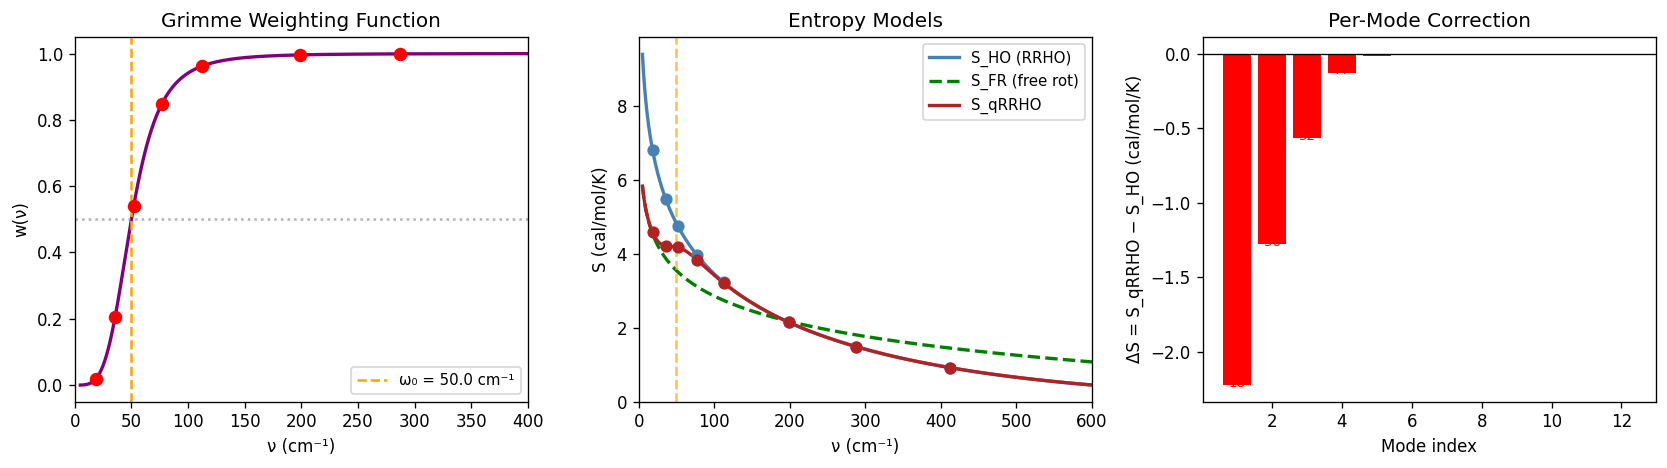

In [8]:
nu_plot = np.linspace(5, 600, 800)

S_ho_plot  = S_HO_vec(nu_plot, T) / 4.184
S_fr_plot  = S_FR_vec(nu_plot, T) / 4.184
S_qr_plot  = S_qRRHO_vec(nu_plot, T, omega0) / 4.184
w_plot     = weight_grimme(nu_plot, omega0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: weighting function
axes[0].plot(nu_plot, w_plot, color='purple', linewidth=2)
axes[0].axvline(omega0, color='orange', linestyle='--', label=f'ω₀ = {omega0} cm⁻¹')
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.6)
axes[0].scatter(freqs, weight_grimme(freqs, omega0), color='red', zorder=5, s=50)
axes[0].set(xlabel='ν (cm⁻¹)', ylabel='w(ν)', title='Grimme Weighting Function',
            xlim=(0, 400), ylim=(-0.05, 1.05))
axes[0].legend(fontsize=9)

# Panel 2: entropy curves
axes[1].plot(nu_plot, S_ho_plot, label='S_HO (RRHO)',   color='steelblue', linewidth=2)
axes[1].plot(nu_plot, S_fr_plot, label='S_FR (free rot)', color='green',    linewidth=2, linestyle='--')
axes[1].plot(nu_plot, S_qr_plot, label='S_qRRHO',        color='firebrick', linewidth=2)
axes[1].axvline(omega0, color='orange', linestyle='--', alpha=0.7)
axes[1].scatter(freqs, S_ho_each, color='steelblue', zorder=5, s=40)
axes[1].scatter(freqs, S_qr_each, color='firebrick', zorder=5, s=40)
axes[1].set(xlabel='ν (cm⁻¹)', ylabel='S (cal/mol/K)',
            title='Entropy Models', xlim=(0, 600), ylim=(0, None))
axes[1].legend(fontsize=9)

# Panel 3: per-mode correction
delta_S = S_qr_each - S_ho_each
colours = ['red' if d < -0.01 else 'gray' for d in delta_S]
axes[2].bar(range(1, len(freqs)+1), delta_S, color=colours, edgecolor='none')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set(xlabel='Mode index', ylabel='ΔS = S_qRRHO − S_HO (cal/mol/K)',
            title='Per-Mode Correction')
for i, (f, d) in enumerate(zip(freqs[:4], delta_S[:4])):
    axes[2].text(i+1, d - 0.01, f'{f:.0f}', ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.show()

The left panel shows that $w = 0.5$ at exactly $\omega_0 = 50$ cm⁻¹ — that is the definition of the cutoff. The middle panel shows that $S_\text{qRRHO}$ is capped: it never grows as steeply as $S_\text{HO}$ toward zero. The right panel shows that the correction is concentrated in the first two modes; for everything above 100 cm⁻¹ the correction is negligible.

---
## Section 10 — Computing the Quasi-RRHO Free Energy

The quasi-RRHO Gibbs free energy is constructed by replacing only $S_\text{vib}$ in Gaussian's RRHO result:

$$G_\text{qRRHO} = H_\text{RRHO} - T\left(S_\text{trans} + S_\text{rot} + S_\text{elec} + S_\text{vib}^\text{qRRHO}\right)$$

Equivalently:

$$G_\text{qRRHO} = G_\text{RRHO} + T\left(S_\text{vib}^\text{RRHO} - S_\text{vib}^\text{qRRHO}\right)$$

Because $S_\text{vib}^\text{qRRHO} \leq S_\text{vib}^\text{RRHO}$ (quasi-RRHO reduces the entropy), the correction is always positive: $G_\text{qRRHO} \geq G_\text{RRHO}$.

In [9]:
def G_qRRHO(thermo_dict, freqs_cm, omega0_cm=50.0):
    """
    Compute the quasi-RRHO Gibbs free energy.

    Parameters
    ----------
    thermo_dict : dict from parse_gaussian_thermo()
    freqs_cm    : array of real vibrational frequencies (cm⁻¹)
    omega0_cm   : quasi-RRHO cutoff frequency (cm⁻¹), default 50

    Returns
    -------
    G_qr        : quasi-RRHO G (Hartree)
    delta_G     : G_qRRHO − G_RRHO (kcal/mol) — always ≥ 0
    """
    T = thermo_dict['temperature']

    # Total RRHO vibrational entropy (J/mol/K)
    S_vib_rrho_J = S_vib_rrho_total(freqs_cm, T)

    # Total quasi-RRHO vibrational entropy (J/mol/K)
    S_vib_qr_J   = np.sum(S_qRRHO_vec(freqs_cm, T, omega0_cm))

    # Entropy correction in Hartree (per mole)
    delta_S_J    = S_vib_qr_J - S_vib_rrho_J            # J/mol/K (negative)
    delta_TS_H   = T * delta_S_J * J_TO_HARTREE          # Hartree (negative)

    G_rrho  = thermo_dict['G_rrho']                      # Hartree
    G_qr    = G_rrho - delta_TS_H                        # subtracting a negative = G increases

    delta_G_kcal = (G_qr - G_rrho) * HARTREE_TO_KCAL    # kcal/mol
    return G_qr, delta_G_kcal


G_qr, delta_G = G_qRRHO(thermo, freqs, omega0_cm=omega0)

print(f"Results at T = {T} K, ω₀ = {omega0} cm⁻¹")
print(f"─────────────────────────────────────────────")
print(f"G_RRHO               : {thermo['G_rrho']:.6f} Hartree")
print(f"G_qRRHO (ω₀=50 cm⁻¹): {G_qr:.6f} Hartree")
print(f"ΔG = G_qRRHO − G_RRHO: {delta_G:+.3f} kcal/mol")
print()
print("ΔG breakdown:")
S_ho_total = sum(S_HO_vec(freqs, T)) / 4.184
S_qr_total = sum(S_qRRHO_vec(freqs, T, omega0)) / 4.184
print(f"  S_vib (RRHO)  = {S_ho_total:.3f} cal/mol/K")
print(f"  S_vib (qRRHO) = {S_qr_total:.3f} cal/mol/K")
print(f"  ΔS_vib        = {S_qr_total - S_ho_total:+.3f} cal/mol/K")
print(f"  −T ΔS_vib     = {-T*(S_qr_total-S_ho_total)/1000*KCAL_TO_KJ/KCAL_TO_KJ:+.3f} kcal/mol")

Results at T = 298.15 K, ω₀ = 50.0 cm⁻¹
─────────────────────────────────────────────
G_RRHO               : -500.136893 Hartree
G_qRRHO (ω₀=50 cm⁻¹): -500.134891 Hartree
ΔG = G_qRRHO − G_RRHO: +1.256 kcal/mol

ΔG breakdown:
  S_vib (RRHO)  = 29.217 cal/mol/K
  S_vib (qRRHO) = 25.003 cal/mol/K
  ΔS_vib        = -4.214 cal/mol/K
  −T ΔS_vib     = +1.256 kcal/mol


The positive $\Delta G$ (quasi-RRHO is less negative than RRHO) reflects the reduced entropy: the quasi-RRHO correction removes the unphysical entropy contribution from the two very soft modes, giving a more realistic free energy. Corrections in the range 0.5–3 kcal/mol are typical for organometallics and host-guest systems with multiple low-frequency modes — large enough to change the predicted order of stability of conformers or the sign of a computed binding energy.

---
## Section 11 — Sensitivity to ω₀

The choice of cutoff frequency is a key methodological decision. Grimme's original paper recommended $\omega_0 = 100$ cm⁻¹; many groups in organometallic and supramolecular chemistry use 50 cm⁻¹; others use 150 cm⁻¹ for very flexible systems. The plot below shows how $\Delta G$ changes as a function of $\omega_0$, which helps build physical intuition for the parameter's role.

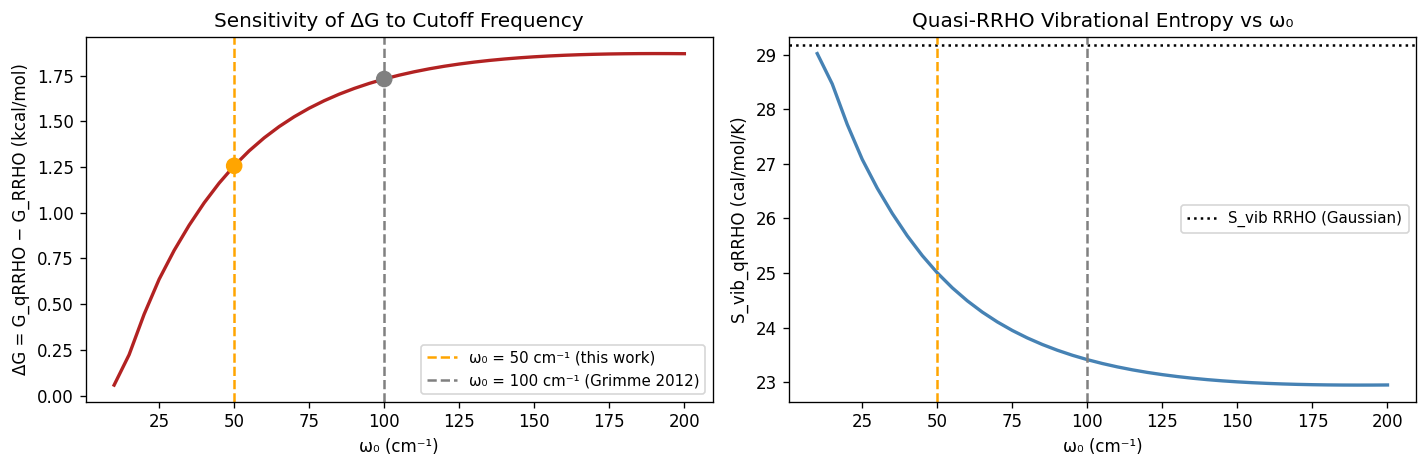

ΔG at ω₀ =  50 cm⁻¹ (default)    : +1.256 kcal/mol
ΔG at ω₀ = 100 cm⁻¹ (Grimme 2012): +1.731 kcal/mol
ΔG at ω₀ = 150 cm⁻¹              : +1.852 kcal/mol


In [10]:
omega0_values = np.arange(10, 201, 5)   # 10 to 200 cm⁻¹
delta_G_values = []
S_qr_values    = []

for om0 in omega0_values:
    G_qr_i, dG_i = G_qRRHO(thermo, freqs, omega0_cm=om0)
    delta_G_values.append(dG_i)
    S_qr_values.append(np.sum(S_qRRHO_vec(freqs, T, om0)) / 4.184)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(omega0_values, delta_G_values, color='firebrick', linewidth=2)
axes[0].axvline(50,  color='orange', linestyle='--', label='ω₀ = 50 cm⁻¹ (this work)')
axes[0].axvline(100, color='gray',   linestyle='--', label='ω₀ = 100 cm⁻¹ (Grimme 2012)')
axes[0].scatter([50, 100], [G_qRRHO(thermo, freqs, 50)[1], G_qRRHO(thermo, freqs, 100)[1]],
                color=['orange', 'gray'], s=80, zorder=5)
axes[0].set(xlabel='ω₀ (cm⁻¹)', ylabel='ΔG = G_qRRHO − G_RRHO (kcal/mol)',
            title='Sensitivity of ΔG to Cutoff Frequency')
axes[0].legend(fontsize=9)

axes[1].plot(omega0_values, S_qr_values, color='steelblue', linewidth=2)
axes[1].axhline(thermo['S_vib_rrho'], color='black', linestyle=':', label='S_vib RRHO (Gaussian)')
axes[1].axvline(50,  color='orange', linestyle='--')
axes[1].axvline(100, color='gray',   linestyle='--')
axes[1].set(xlabel='ω₀ (cm⁻¹)', ylabel='S_vib_qRRHO (cal/mol/K)',
            title='Quasi-RRHO Vibrational Entropy vs ω₀')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"ΔG at ω₀ =  50 cm⁻¹ (default)    : {G_qRRHO(thermo, freqs, 50)[1]:+.3f} kcal/mol")
print(f"ΔG at ω₀ = 100 cm⁻¹ (Grimme 2012): {G_qRRHO(thermo, freqs, 100)[1]:+.3f} kcal/mol")
print(f"ΔG at ω₀ = 150 cm⁻¹              : {G_qRRHO(thermo, freqs, 150)[1]:+.3f} kcal/mol")

The $\Delta G$ curve is monotonically increasing with $\omega_0$ — larger cutoffs correct more modes and raise $G$ more. The curve flattens above ~150 cm⁻¹ because all modes in the problematic low-frequency region are already fully corrected and only modes that were already well-behaved remain. This plateau behaviour is what gives confidence that the method is not arbitrarily sensitive to the exact choice of $\omega_0$ in the physically motivated range of 50–100 cm⁻¹.

---
## Section 12 — A Reusable Thermochemistry Function

The cell below packages everything into a single function that accepts any Gaussian frequency output file and returns a structured report of RRHO and quasi-RRHO thermochemistry. This is the function you would call in a script that processes many output files from a conformer search or reaction profile.

In [11]:
def thermochemistry_report(filename, omega0_cm=50.0, T_override=None):
    """
    Compute RRHO and quasi-RRHO thermochemistry from a Gaussian 16 frequency output.

    Parameters
    ----------
    filename   : path to Gaussian .log file
    omega0_cm  : quasi-RRHO cutoff frequency in cm⁻¹ (default 50)
    T_override : override the temperature from the log file (K), or None to use Gaussian's

    Returns
    -------
    dict with keys:
      E_elec, ZPE, H, G_rrho, G_qrrho (all in Hartree)
      S_vib_rrho, S_vib_qrrho (cal/mol/K)
      delta_G_kcal   — G_qRRHO − G_RRHO in kcal/mol
      freqs          — array of real frequencies (cm⁻¹)
      n_imag         — number of imaginary frequencies
    """
    thermo   = parse_gaussian_thermo(filename)
    freqs, imag = parse_frequencies(filename)

    T = T_override if T_override is not None else thermo['temperature']

    G_qr, delta_G = G_qRRHO(thermo, freqs, omega0_cm=omega0_cm)

    S_vib_r  = np.sum(S_HO_vec(freqs, T)) / 4.184
    S_vib_qr = np.sum(S_qRRHO_vec(freqs, T, omega0_cm)) / 4.184

    result = {
        'E_elec'       : thermo['E_elec'],
        'ZPE'          : thermo['ZPE'],
        'H'            : thermo['E_elec'] + thermo['H_corr'],
        'G_rrho'       : thermo['G_rrho'],
        'G_qrrho'      : G_qr,
        'S_vib_rrho'   : S_vib_r,
        'S_vib_qrrho'  : S_vib_qr,
        'delta_G_kcal' : delta_G,
        'freqs'        : freqs,
        'n_imag'       : len(imag),
        'T'            : T,
        'omega0'       : omega0_cm,
    }
    return result


def print_thermo_report(res):
    """Pretty-print a thermochemistry report dictionary."""
    print(f"\n{'─'*58}")
    print(f" Thermochemistry Report")
    print(f" T = {res['T']} K  |  ω₀ = {res['omega0']} cm⁻¹  |  Imaginary modes: {res['n_imag']}")
    print(f"{'─'*58}")
    print(f"  E_elec     : {res['E_elec']:>15.6f} Hartree")
    print(f"  ZPE        : {res['ZPE']:>15.6f} Hartree  ({res['ZPE']*HARTREE_TO_KCAL:.2f} kcal/mol)")
    print(f"  H          : {res['H']:>15.6f} Hartree")
    print(f"  G (RRHO)   : {res['G_rrho']:>15.6f} Hartree")
    print(f"  G (qRRHO)  : {res['G_qrrho']:>15.6f} Hartree")
    print(f"  ΔG (qR-RR) : {res['delta_G_kcal']:>+14.3f} kcal/mol")
    print(f"{'─'*58}")
    print(f"  S_vib RRHO : {res['S_vib_rrho']:>10.3f} cal/mol/K")
    print(f"  S_vib qRRHO: {res['S_vib_qrrho']:>10.3f} cal/mol/K")
    print(f"  Frequencies: {len(res['freqs'])} real modes, range {res['freqs'].min():.1f}–{res['freqs'].max():.1f} cm⁻¹")
    n_low = np.sum(res['freqs'] < res['omega0'])
    print(f"  Modes < ω₀ : {n_low} (receive largest qRRHO correction)")
    print(f"{'─'*58}\n")


# ── Run on the example file with default ω₀ = 50 cm⁻¹ ──────────────────
report_50  = thermochemistry_report("example_freq.log", omega0_cm=50.0)
report_100 = thermochemistry_report("example_freq.log", omega0_cm=100.0)

print_thermo_report(report_50)

print("Comparison of default (50 cm⁻¹) vs Grimme 2012 default (100 cm⁻¹):")
print(f"  ΔG at ω₀ = 50  cm⁻¹: {report_50['delta_G_kcal']:+.3f} kcal/mol")
print(f"  ΔG at ω₀ = 100 cm⁻¹: {report_100['delta_G_kcal']:+.3f} kcal/mol")


──────────────────────────────────────────────────────────
 Thermochemistry Report
 T = 298.15 K  |  ω₀ = 50.0 cm⁻¹  |  Imaginary modes: 0
──────────────────────────────────────────────────────────
  E_elec     :     -500.123457 Hartree
  ZPE        :        0.020895 Hartree  (13.11 kcal/mol)
  H          :     -500.093242 Hartree
  G (RRHO)   :     -500.136893 Hartree
  G (qRRHO)  :     -500.134891 Hartree
  ΔG (qR-RR) :         +1.256 kcal/mol
──────────────────────────────────────────────────────────
  S_vib RRHO :     29.217 cal/mol/K
  S_vib qRRHO:     25.003 cal/mol/K
  Frequencies: 12 real modes, range 18.4–3089.7 cm⁻¹
  Modes < ω₀ : 2 (receive largest qRRHO correction)
──────────────────────────────────────────────────────────

Comparison of default (50 cm⁻¹) vs Grimme 2012 default (100 cm⁻¹):
  ΔG at ω₀ = 50  cm⁻¹: +1.256 kcal/mol
  ΔG at ω₀ = 100 cm⁻¹: +1.731 kcal/mol


---
## Summary

This notebook walked through a complete thermochemistry pipeline from Gaussian output to quasi-RRHO free energy:

1. **Parsing**: `parse_gaussian_thermo()` and `parse_frequencies()` extract everything you need from a `.log` file.

2. **RRHO verification**: The harmonic oscillator entropy formula reproduces Gaussian's reported $S_\text{vib}$ exactly, confirming we understand what Gaussian computes.

3. **The problem**: $S_\text{HO}$ diverges logarithmically at low frequencies. A single 18 cm⁻¹ mode can contribute more entropy than five mid-frequency modes combined — and the harmonic oscillator is not physically justified for such motion.

4. **Quasi-RRHO solution** (Grimme 2012): smooth interpolation between $S_\text{HO}$ and a free rotor $S_\text{FR}$ using the weight $w = 1/(1+(\omega_0/\nu)^4)$. The correction is concentrated in modes below $\omega_0$ and is zero for all high-frequency modes.

5. **Default cutoff**: $\omega_0 = 50$ cm⁻¹ (Grimme's original recommendation is 100 cm⁻¹; 50 cm⁻¹ is appropriate when modes in the 50–100 cm⁻¹ range are genuine vibrations that should be treated as harmonic).

**Recommended reading:**
- Grimme, S. *Chem. Eur. J.* **2012**, 18, 9955–9964 — original quasi-RRHO paper
- Ochterski, J. W. *Thermochemistry in Gaussian*, Gaussian Inc. white paper (2000) — complete RRHO equations
- Luchini, G.; Alegre-Requena, J. V.; Guan, Y.; Paton, R. S. *F1000Research* **2020** — GoodVibes, a production-quality implementation

**Next steps:**
- Apply `thermochemistry_report()` to a series of conformers generated by Gaussian and compare their $G_\text{qRRHO}$ values to find the most stable conformer.
- Combine with the Part 2 parser (which already extracts electronic energies) and Part 3's RMSD filter (to remove duplicate conformers) for a complete post-processing pipeline.